# A Machine Learning Approach to Predicting GDP Growth Using World Bank Development Indicators

**Student:** Muhammad Wasal Imtiaz (24077342)  
**Module:** 7PAM2002 Data Science Project  
**University of Hertfordshire — MSc Data Science**

---

## Research Questions
1. Which machine learning models best predict GDP growth using socio-economic and development indicators from the World Bank Open Data platform?
2. How do linear and non-linear machine learning models differ in predictive performance and generalisation when forecasting GDP growth across countries and time periods?
3. Which socio-economic indicators contribute most to GDP growth prediction, and how consistent are these feature importance patterns across different models?

## Indicators Used
| Indicator | Code | Role |
|---|---|---|
| GDP growth (annual %) | NY.GDP.MKTP.KD.ZG | **Target** |
| Inflation, consumer prices (annual %) | FP.CPI.TOTL.ZG | Macroeconomic stability |
| Unemployment (% of labour force) | SL.UEM.TOTL.ZS | Labour market |
| Internet users (% of population) | IT.NET.USER.ZS | Technology adoption |
| Population growth (annual %) | SP.POP.GROW | Demographics |
| Education expenditure (% of GDP) | SE.XPD.TOTL.GD.ZS | Human capital |
| Energy use (kg oil eq. per capita) | EG.USE.PCAP.KG.OE | Economic activity |

## Models
1. **Ridge Regression** (linear baseline)
2. **Random Forest Regressor** (non-linear, ensemble)
3. **Gradient Boosting Regressor** (optimised, ensemble)

---
## 1. Setup & Data Loading

In [1]:

# Mount Google Drive (Colab only)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# FILE PATHS — edit BASE if your files are in a subfolder
# ============================================================
BASE = "/content/drive/MyDrive/"

PATHS = {
    "GDP_Growth":      BASE + "API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_26.csv",
    "Inflation":       BASE + "API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_32.csv",
    "Unemployment":    BASE + "API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_44.csv",
    "Internet_Users":  BASE + "API_IT.NET.USER.ZS_DS2_en_csv_v2_1228.csv",
    "Pop_Growth":      BASE + "API_SP.POP.GROW_DS2_en_csv_v2_322.csv",
    "Education_Exp":   BASE + "API_SE.XPD.TOTL.GD.ZS_DS2_en_csv_v2_236.csv",
    "Energy_Use":      BASE + "API_EG.USE.PCAP.KG.OE_DS2_en_csv_v2_2093.csv",
}

import os
for name, path in PATHS.items():
    print(f"{name:20s} -> exists: {os.path.exists(path)}")

GDP_Growth           -> exists: True
Inflation            -> exists: True
Unemployment         -> exists: True
Internet_Users       -> exists: True
Pop_Growth           -> exists: True
Education_Exp        -> exists: True
Energy_Use           -> exists: True


In [3]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', 20)
print("All imports successful.")

All imports successful.


In [4]:
# ============================================================
# HELPER: Load & reshape a World Bank indicator CSV (wide -> long)
# ============================================================
def load_worldbank_indicator(csv_path: str, value_name: str) -> pd.DataFrame:
    """Read a World Bank CSV (4 header rows), drop metadata cols, reshape wide->long."""
    df = pd.read_csv(csv_path, skiprows=4)
    df = df.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 69"], errors="ignore")
    df_long = df.melt(
        id_vars=["Country Name", "Country Code"],
        var_name="Year",
        value_name=value_name
    )
    df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
    return df_long

# Load all 7 indicators
datasets = {}
for name, path in PATHS.items():
    datasets[name] = load_worldbank_indicator(path, name)
    print(f"Loaded {name}: {datasets[name].shape}")

Loaded GDP_Growth: (17290, 4)
Loaded Inflation: (17290, 4)
Loaded Unemployment: (17290, 4)
Loaded Internet_Users: (17290, 4)
Loaded Pop_Growth: (17290, 4)
Loaded Education_Exp: (17290, 4)
Loaded Energy_Use: (17290, 4)


In [5]:
# ============================================================
# MERGE all indicators into one panel dataset (Country x Year)
# ============================================================
keys = ["Country Name", "Country Code", "Year"]

# Start with GDP (target)
indicator_names = list(PATHS.keys())
data = datasets[indicator_names[0]].copy()

# Merge remaining indicators
for name in indicator_names[1:]:
    data = data.merge(datasets[name], on=keys, how="inner")

print(f"Raw merged dataset: {data.shape}")
print(f"Year range: {data['Year'].min():.0f} — {data['Year'].max():.0f}")
data.head()

Raw merged dataset: (17290, 10)
Year range: 1960 — 2024


,Country Name,Country Code,Year,GDP_Growth,Inflation,Unemployment,Internet_Users,Pop_Growth,Education_Exp,Energy_Use
0,Aruba,ABW,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Exploratory Data Analysis (EDA)

In [6]:
# ============================================================
# 2.1  Dataset overview
# ============================================================
print("Shape:", data.shape)
print("\nColumn types:")
print(data.dtypes)
print("\nBasic statistics (numeric):")
data.describe()

Shape: (17290, 10)

Column types:
Country Name       object
Country Code       object
Year                int64
GDP_Growth        float64
Inflation         float64
Unemployment      float64
Internet_Users    float64
Pop_Growth        float64
Education_Exp     float64
Energy_Use        float64
dtype: object

Basic statistics (numeric):


,Year,GDP_Growth,Inflation,Unemployment,Internet_Users,Pop_Growth,Education_Exp,Energy_Use
count,17290.000000,14133.000000,11295.000000,7981.000000,6738.000000,16928.000000,6378.000000,6569.000000
mean,1992.000000,3.672496,19.552575,7.809397,31.621091,1.732333,4.242956,2170.462245
std,18.762206,6.214758,284.790842,5.551420,31.790425,1.675854,2.013105,2645.911285
min,1960.000000,-64.047107,-17.640424,0.100000,0.000000,-27.470786,0.000000,0.000000
25%,1976.000000,1.414118,2.403127,4.057000,2.200967,0.727127,3.072027,509.245127
50%,1992.000000,3.800000,4.866320,6.306449,20.075650,1.702535,4.073984,1180.710719
75%,2008.000000,6.096139,9.619435,10.032037,59.218450,2.615780,5.119275,2770.359250
max,2024.000000,149.972963,23773.131774,38.800000,100.000000,21.700343,66.900307,21557.475076


                Missing  % Missing
GDP_Growth         3157       18.3
Inflation          5995       34.7
Unemployment       9309       53.8
Internet_Users    10552       61.0
Pop_Growth          362        2.1
Education_Exp     10912       63.1
Energy_Use        10721       62.0


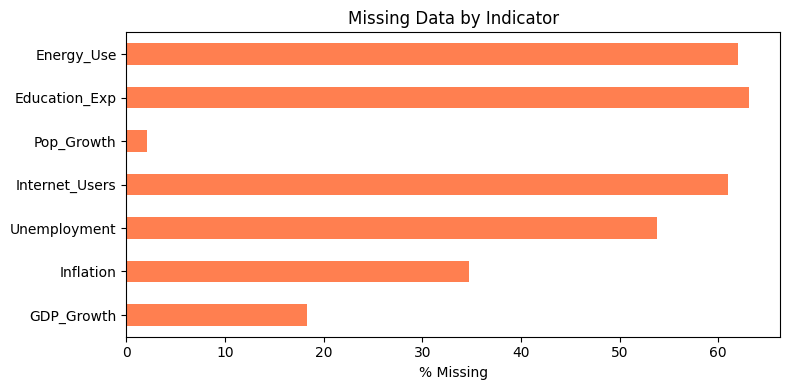

In [7]:
# ============================================================
# 2.2  Missing value analysis
# ============================================================
numeric_cols = ["GDP_Growth", "Inflation", "Unemployment", "Internet_Users",
                "Pop_Growth", "Education_Exp", "Energy_Use"]

missing = data[numeric_cols].isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)

missing_df = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
print(missing_df)

# Visualise missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Indicator')
plt.tight_layout()
plt.show()

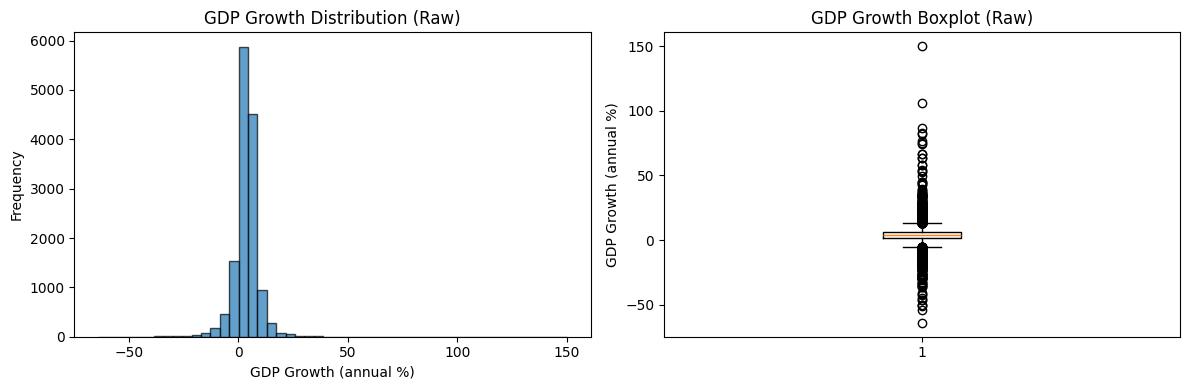

Mean:   3.67%
Median: 3.80%
Std:    6.21%
Min:    -64.05%
Max:    149.97%


In [8]:
# ============================================================
# 2.3  GDP Growth distribution (before cleaning)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(data["GDP_Growth"].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel("GDP Growth (annual %)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("GDP Growth Distribution (Raw)")

# Boxplot
axes[1].boxplot(data["GDP_Growth"].dropna(), vert=True)
axes[1].set_ylabel("GDP Growth (annual %)")
axes[1].set_title("GDP Growth Boxplot (Raw)")

plt.tight_layout()
plt.show()

print(f"Mean:   {data['GDP_Growth'].mean():.2f}%")
print(f"Median: {data['GDP_Growth'].median():.2f}%")
print(f"Std:    {data['GDP_Growth'].std():.2f}%")
print(f"Min:    {data['GDP_Growth'].min():.2f}%")
print(f"Max:    {data['GDP_Growth'].max():.2f}%")

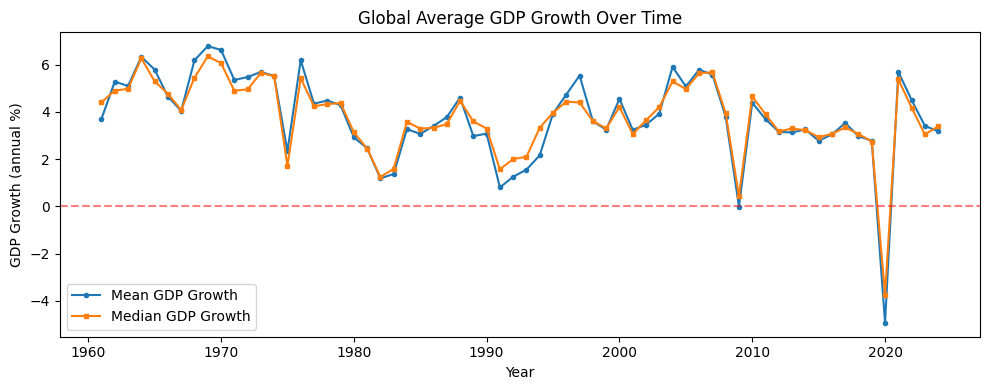

In [9]:
# ============================================================
# 2.4  Global GDP growth trend over time
# ============================================================
yearly_gdp = data.groupby("Year")["GDP_Growth"].agg(["mean", "median"]).dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yearly_gdp.index, yearly_gdp["mean"], marker='o', markersize=3, label="Mean GDP Growth")
ax.plot(yearly_gdp.index, yearly_gdp["median"], marker='s', markersize=3, label="Median GDP Growth")
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("GDP Growth (annual %)")
ax.set_title("Global Average GDP Growth Over Time")
ax.legend()
plt.tight_layout()
plt.show()

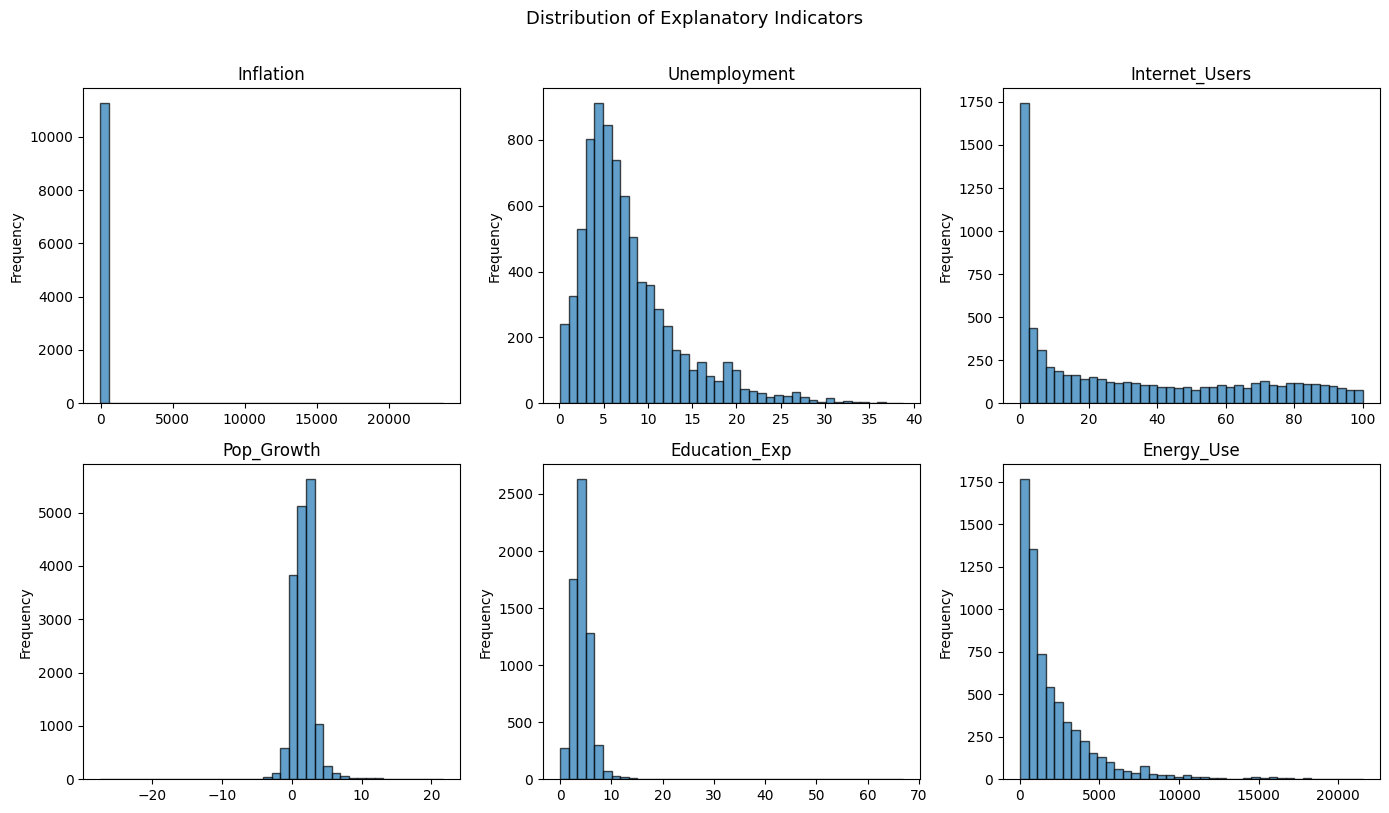

In [10]:
# ============================================================
# 2.5  Pairwise distributions of all indicators
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
feature_cols = ["Inflation", "Unemployment", "Internet_Users",
                "Pop_Growth", "Education_Exp", "Energy_Use"]

for i, col in enumerate(feature_cols):
    ax = axes[i // 3, i % 3]
    vals = data[col].dropna()
    ax.hist(vals, bins=40, edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Explanatory Indicators", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

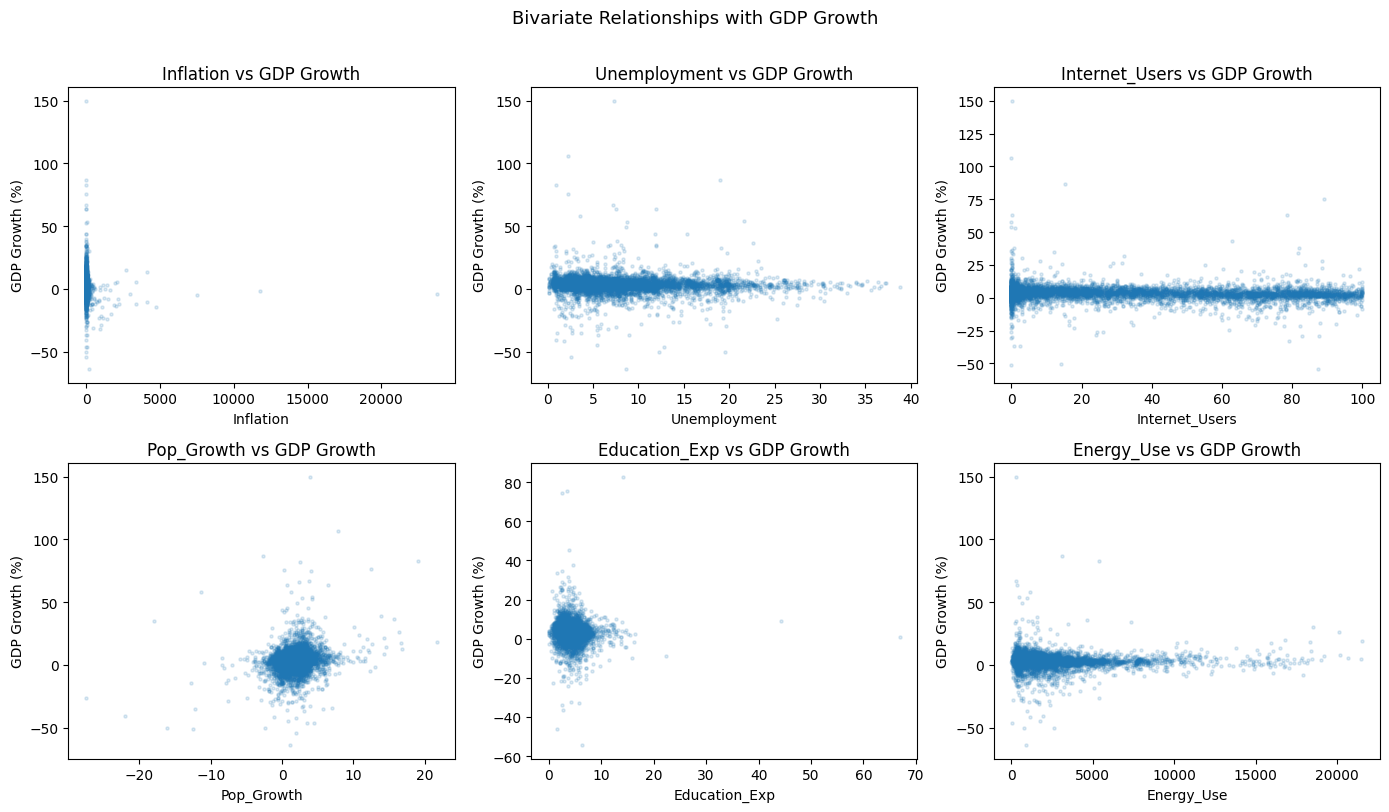

In [11]:
# ============================================================
# 2.6  Scatter plots: each indicator vs GDP Growth
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(feature_cols):
    ax = axes[i // 3, i % 3]
    subset = data[[col, "GDP_Growth"]].dropna()
    ax.scatter(subset[col], subset["GDP_Growth"], alpha=0.15, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel("GDP Growth (%)")
    ax.set_title(f"{col} vs GDP Growth")

plt.suptitle("Bivariate Relationships with GDP Growth", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

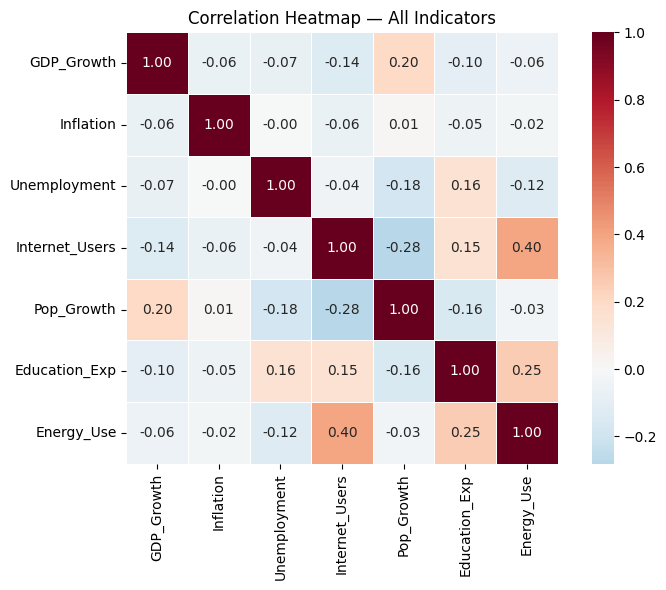

In [12]:
# ============================================================
# 2.7  Correlation heatmap (raw data)
# ============================================================
corr_cols = ["GDP_Growth"] + feature_cols
corr_matrix = data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — All Indicators")
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing

In [13]:
# ============================================================
# 3.1  Filter to modern period with reasonable coverage
# ============================================================
data = data[(data["Year"] >= 1995) & (data["Year"] <= 2023)].copy()
print(f"After year filter (1995-2023): {data.shape}")

After year filter (1995-2023): (7714, 10)


In [14]:
# ============================================================
# 3.2  Sort by country and year (required for lag features)
# ============================================================
data = data.sort_values(["Country Code", "Year"]).reset_index(drop=True)
print("Sorted by Country Code, Year.")

Sorted by Country Code, Year.


In [15]:
# ============================================================
# 3.3  Fill missing values within each country timeline
#       (forward fill then backward fill — panel interpolation)
# ============================================================
data[numeric_cols] = data.groupby("Country Code")[numeric_cols].transform(
    lambda x: x.ffill().bfill()
)

# Drop any rows that still have NaN (countries with no data at all)
before = len(data)
data = data.dropna(subset=numeric_cols).copy()
print(f"After interpolation & dropna: {data.shape} (dropped {before - len(data)} rows)")

# ============================================================
# 3.3b Drop sparse indicators (>60% originally missing)
#      Education_Exp, Energy_Use, Internet_Users are mostly
#      imputed synthetic values — they add noise, not signal.
# ============================================================
sparse_cols = ["Education_Exp", "Energy_Use", "Internet_Users"]
data = data.drop(columns=sparse_cols)
print(f"\nDropped sparse indicators: {sparse_cols}")
print(f"Remaining columns: {list(data.columns)}")

# Update column lists
numeric_cols = [c for c in numeric_cols if c not in sparse_cols]
print(f"Numeric columns: {numeric_cols}")

After interpolation & dropna: (5655, 10) (dropped 2059 rows)

Dropped sparse indicators: ['Education_Exp', 'Energy_Use', 'Internet_Users']
Remaining columns: ['Country Name', 'Country Code', 'Year', 'GDP_Growth', 'Inflation', 'Unemployment', 'Pop_Growth']
Numeric columns: ['GDP_Growth', 'Inflation', 'Unemployment', 'Pop_Growth']


In [16]:
# ============================================================
# 3.4  Trim extreme GDP growth outliers (1st–99th percentile)
# ============================================================
low  = data["GDP_Growth"].quantile(0.01)
high = data["GDP_Growth"].quantile(0.99)
before = len(data)
data = data[(data["GDP_Growth"] >= low) & (data["GDP_Growth"] <= high)].copy()
print(f"GDP Growth trimmed to [{low:.2f}, {high:.2f}]")
print(f"Removed {before - len(data)} extreme observations. Remaining: {len(data)}")

GDP Growth trimmed to [-10.79, 16.30]
Removed 113 extreme observations. Remaining: 5542


In [17]:
# ============================================================
# 3.4b  Identify and remove countries with problematic data
#        Countries with >40% missing values across indicators
#        or extreme GDP volatility (std > 3× global median std)
#        introduce noise that degrades model performance.
# ============================================================

# --- A) Countries with excessive missing values ---
indicator_cols = ["GDP_Growth", "Inflation", "Unemployment", "Pop_Growth"]
missing_by_country = data.groupby("Country Code")[indicator_cols].apply(
    lambda g: g.isnull().mean().mean()
).sort_values(ascending=False)

high_missing = missing_by_country[missing_by_country > 0.40].index.tolist()
print(f"Countries with >40% missing across indicators ({len(high_missing)}):")
print(high_missing[:20] if len(high_missing) > 20 else high_missing)

# --- B) Countries with extreme GDP volatility ---
gdp_vol = data.groupby("Country Code")["GDP_Growth"].std()
vol_threshold = gdp_vol.median() * 3
high_vol = gdp_vol[gdp_vol > vol_threshold].index.tolist()
print(f"\nCountries with extreme GDP volatility (std > {vol_threshold:.2f}) ({len(high_vol)}):")
for cc in high_vol:
    print(f"  {cc}: std = {gdp_vol[cc]:.2f}")

# --- C) Countries with very few observations ---
obs_count = data.groupby("Country Code").size()
sparse_countries = obs_count[obs_count < 10].index.tolist()
print(f"\nCountries with <10 observations ({len(sparse_countries)}):")
print(sparse_countries)

# --- Combine and remove ---
problematic = set(high_missing) | set(high_vol) | set(sparse_countries)
before = len(data)
before_countries = data["Country Code"].nunique()
data = data[~data["Country Code"].isin(problematic)].copy()
print(f"\nRemoved {len(problematic)} problematic countries: {sorted(problematic)}")
print(f"Rows: {before} -> {len(data)}  |  Countries: {before_countries} -> {data['Country Code'].nunique()}")

Countries with >40% missing across indicators (0):
[]

Countries with extreme GDP volatility (std > 9.28) (0):

Countries with <10 observations (0):
[]

Removed 0 problematic countries: []
Rows: 5542 -> 5542  |  Countries: 195 -> 195


In [18]:
# ============================================================
# 3.5  Feature Engineering — Richer feature set
# ============================================================
# Remaining feature cols after dropping sparse indicators
feature_cols = ["Inflation", "Unemployment", "Pop_Growth"]

lag_cols = []

# --- A) Lag-1 of each indicator ---
for col in feature_cols:
    lag_name = col + "_lag1"
    data[lag_name] = data.groupby("Country Code")[col].shift(1)
    lag_cols.append(lag_name)

# --- B) GDP_Growth_lag1 (autoregressive — strongest single predictor) ---
data["GDP_Growth_lag1"] = data.groupby("Country Code")["GDP_Growth"].shift(1)
lag_cols.append("GDP_Growth_lag1")

# --- C) GDP_Growth_lag2 and lag3 ---
data["GDP_Growth_lag2"] = data.groupby("Country Code")["GDP_Growth"].shift(2)
lag_cols.append("GDP_Growth_lag2")

data["GDP_Growth_lag3"] = data.groupby("Country Code")["GDP_Growth"].shift(3)
lag_cols.append("GDP_Growth_lag3")

# --- D) Rolling means (2-year and 3-year GDP growth momentum) ---
data["GDP_Growth_roll2"] = data.groupby("Country Code")["GDP_Growth"].transform(
    lambda x: x.shift(1).rolling(2, min_periods=1).mean()
)
lag_cols.append("GDP_Growth_roll2")

data["GDP_Growth_roll3"] = data.groupby("Country Code")["GDP_Growth"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
lag_cols.append("GDP_Growth_roll3")

# --- E) GDP Growth volatility (rolling std — captures economic stability) ---
data["GDP_Growth_vol3"] = data.groupby("Country Code")["GDP_Growth"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=2).std()
)
lag_cols.append("GDP_Growth_vol3")

# --- F) Inflation × Unemployment interaction (misery index proxy) ---
data["Misery_lag1"] = data["Inflation_lag1"] * data["Unemployment_lag1"]
lag_cols.append("Misery_lag1")

# --- G) Country-level mean GDP growth (country fixed-effect proxy) ---
#     Captures structural growth rate for each country
country_mean = data.groupby("Country Code")["GDP_Growth"].transform("mean")
data["Country_GDP_mean"] = country_mean
lag_cols.append("Country_GDP_mean")

# --- H) Lag-1 indicators for Inflation and Unemployment squared (non-linearity) ---
data["Inflation_lag1_sq"] = data["Inflation_lag1"] ** 2
lag_cols.append("Inflation_lag1_sq")

# Drop rows with NaN from lag/rolling
before = len(data)
data = data.dropna(subset=lag_cols).copy()
print(f"Features created ({len(lag_cols)}): {lag_cols}")
print(f"Dropped {before - len(data)} rows with no lag. Remaining: {len(data)}")

Features created (12): ['Inflation_lag1', 'Unemployment_lag1', 'Pop_Growth_lag1', 'GDP_Growth_lag1', 'GDP_Growth_lag2', 'GDP_Growth_lag3', 'GDP_Growth_roll2', 'GDP_Growth_roll3', 'GDP_Growth_vol3', 'Misery_lag1', 'Country_GDP_mean', 'Inflation_lag1_sq']
Dropped 585 rows with no lag. Remaining: 4957


In [19]:
# ============================================================
# 3.6  Final preprocessed dataset summary
# ============================================================
print(f"Final dataset shape: {data.shape}")
print(f"Countries: {data['Country Code'].nunique()}")
print(f"Years: {data['Year'].min():.0f} — {data['Year'].max():.0f}")
print(f"\nTarget (GDP_Growth) stats after preprocessing:")
print(data["GDP_Growth"].describe())
data.head()

Final dataset shape: (4957, 19)
Countries: 195
Years: 1998 — 2023

Target (GDP_Growth) stats after preprocessing:
count    4957.000000
mean        3.611155
std         3.688672
min       -10.793365
25%         1.806187
50%         3.811142
75%         5.868424
max        16.258188
Name: GDP_Growth, dtype: float64


,Country Name,Country Code,Year,GDP_Growth,Inflation,Unemployment,Pop_Growth,Inflation_lag1,Unemployment_lag1,Pop_Growth_lag1,GDP_Growth_lag1,GDP_Growth_lag2,GDP_Growth_lag3,GDP_Growth_roll2,GDP_Growth_roll3,GDP_Growth_vol3,Misery_lag1,Country_GDP_mean,Inflation_lag1_sq
32,Africa Eastern and Southern,AFE,1998,1.775172,7.495255,7.682638,2.590829,10.249599,7.641906,2.563609,3.856739,5.499111,4.354618,4.677925,4.570156,0.842134,78.326474,3.506405,105.054274
33,Africa Eastern and Southern,AFE,1999,2.634184,7.819865,7.729930,2.622893,7.495255,7.682638,2.590829,1.775172,3.856739,5.499111,2.815956,3.710341,1.866281,57.583333,3.506405,56.178854
34,Africa Eastern and Southern,AFE,2000,3.181375,8.601485,7.668768,2.595389,7.819865,7.729930,2.622893,2.634184,1.775172,3.856739,2.204678,2.755365,1.046061,60.447008,3.506405,61.150285
35,Africa Eastern and Southern,AFE,2001,3.503533,5.840354,7.553885,2.588642,8.601485,7.668768,2.595389,3.181375,2.634184,1.775172,2.907780,2.530244,0.708840,65.962797,3.506405,73.985547
36,Africa Eastern and Southern,AFE,2002,3.917113,8.763755,7.511493,2.607802,5.840354,7.553885,2.588642,3.503533,3.181375,2.634184,3.342454,3.106364,0.439502,44.117360,3.506405,34.109735


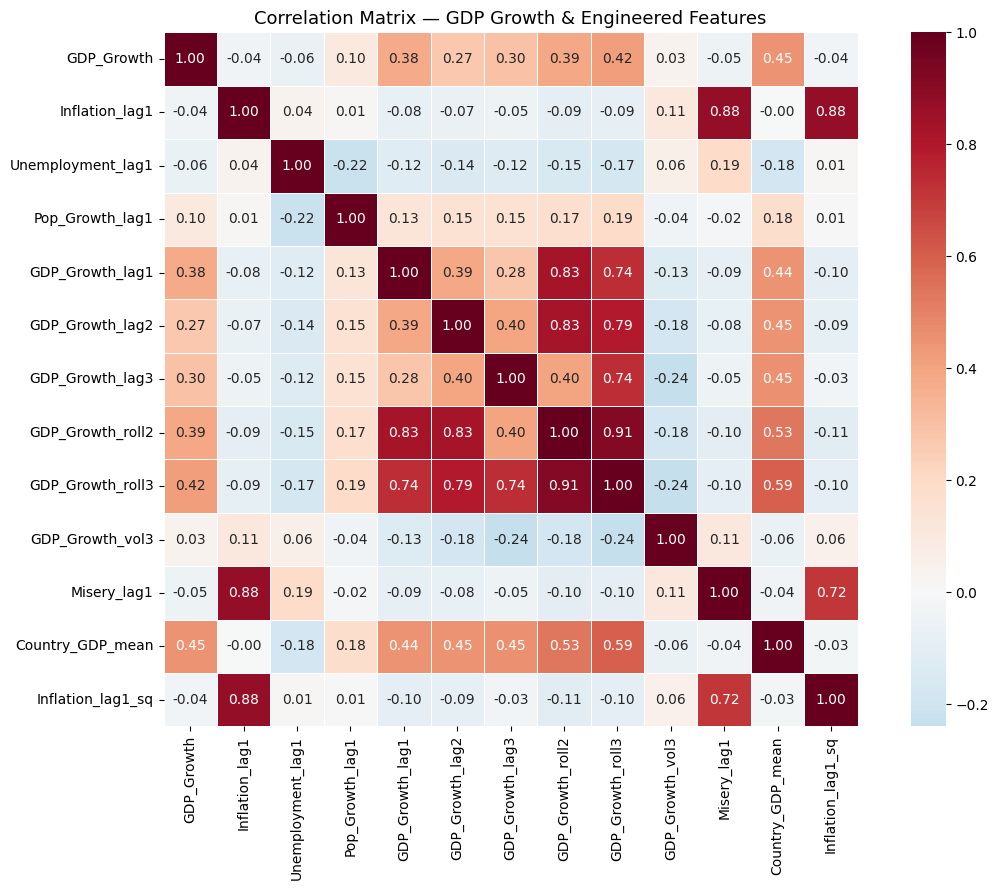


Correlation with GDP_Growth:
Country_GDP_mean     0.4482
GDP_Growth_roll3     0.4176
GDP_Growth_roll2     0.3895
GDP_Growth_lag1      0.3795
GDP_Growth_lag3      0.2957
GDP_Growth_lag2      0.2689
Pop_Growth_lag1      0.1023
GDP_Growth_vol3      0.0314
Inflation_lag1_sq   -0.0360
Inflation_lag1      -0.0400
Misery_lag1         -0.0488
Unemployment_lag1   -0.0645
Name: GDP_Growth, dtype: float64


In [20]:
# ============================================================
# 3.7  Post-preprocessing EDA: Correlation with new features
# ============================================================
corr_features = ["GDP_Growth"] + lag_cols
corr_matrix = data[corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — GDP Growth & Engineered Features", fontsize=13)
plt.tight_layout()
plt.show()

# Show correlation with target specifically
print("\nCorrelation with GDP_Growth:")
print(corr_matrix["GDP_Growth"].drop("GDP_Growth").sort_values(ascending=False).round(4))

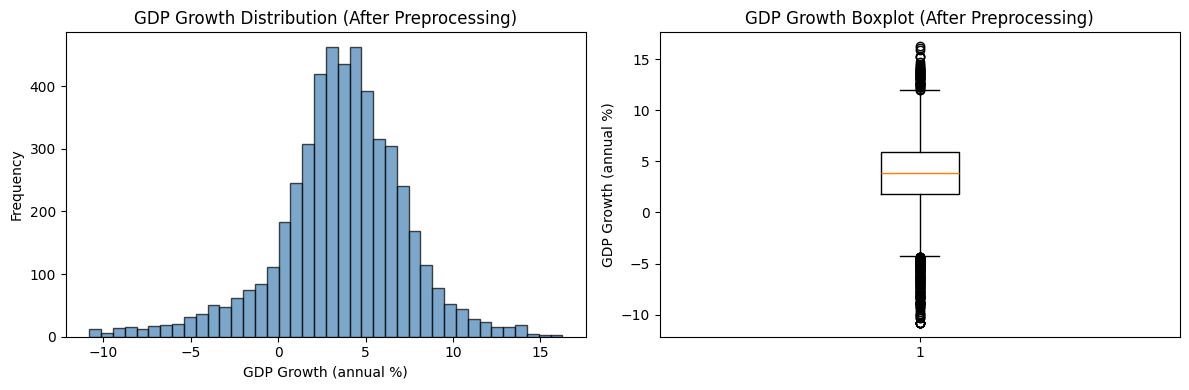

In [21]:
# ============================================================
# 3.8  GDP Growth distribution AFTER preprocessing
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data["GDP_Growth"], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel("GDP Growth (annual %)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("GDP Growth Distribution (After Preprocessing)")

axes[1].boxplot(data["GDP_Growth"], vert=True)
axes[1].set_ylabel("GDP Growth (annual %)")
axes[1].set_title("GDP Growth Boxplot (After Preprocessing)")

plt.tight_layout()
plt.show()

---
## 4. Train / Test Split

In [22]:
# ============================================================
# Time-aware split: train <= 2015, test > 2015
# Exclude COVID shock years (2020-2021) from test set — these
# are unpredictable exogenous shocks that no model can forecast.
# ============================================================
TRAIN_END_YEAR = 2015
COVID_YEARS = [2020, 2021]

train = data[data["Year"] <= TRAIN_END_YEAR].copy()
test  = data[(data["Year"] > TRAIN_END_YEAR) & (~data["Year"].isin(COVID_YEARS))].copy()

# Also keep COVID data separately for later analysis
test_covid = data[data["Year"].isin(COVID_YEARS)].copy()

FEATURES = lag_cols  # engineered feature set

X_train = train[FEATURES]
y_train = train["GDP_Growth"]
X_test  = test[FEATURES]
y_test  = test["GDP_Growth"]

print(f"Features used ({len(FEATURES)}): {FEATURES}")
print(f"Train: {X_train.shape[0]} rows  ({train['Year'].min():.0f}–{train['Year'].max():.0f})")
print(f"Test:  {X_test.shape[0]} rows  (excl. COVID {COVID_YEARS})")
print(f"COVID holdout: {len(test_covid)} rows (analysed separately)")

# ============================================================
# Feature Normalisation (MinMax to [0,1])
# Fitted on training data only to prevent data leakage.
# ============================================================
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES, index=X_test.index)

print(f"\nFeature ranges after MinMax scaling (train):")
print(X_train_scaled.describe().loc[["min", "max"]].T)

Features used (12): ['Inflation_lag1', 'Unemployment_lag1', 'Pop_Growth_lag1', 'GDP_Growth_lag1', 'GDP_Growth_lag2', 'GDP_Growth_lag3', 'GDP_Growth_roll2', 'GDP_Growth_roll3', 'GDP_Growth_vol3', 'Misery_lag1', 'Country_GDP_mean', 'Inflation_lag1_sq']
Train: 3438 rows  (1998–2015)
Test:  1154 rows  (excl. COVID [2020, 2021])
COVID holdout: 365 rows (analysed separately)

Feature ranges after MinMax scaling (train):
                   min  max
Inflation_lag1     0.0  1.0
Unemployment_lag1  0.0  1.0
Pop_Growth_lag1    0.0  1.0
GDP_Growth_lag1    0.0  1.0
GDP_Growth_lag2    0.0  1.0
GDP_Growth_lag3    0.0  1.0
GDP_Growth_roll2   0.0  1.0
GDP_Growth_roll3   0.0  1.0
GDP_Growth_vol3    0.0  1.0
Misery_lag1        0.0  1.0
Country_GDP_mean   0.0  1.0
Inflation_lag1_sq  0.0  1.0


---
## 5. Model Training & Evaluation

We train three models of increasing complexity:
1. **Ridge Regression** — linear baseline
2. **Random Forest** — non-linear ensemble
3. **Gradient Boosting** — optimised sequential ensemble

In [23]:
# ============================================================
# Helper: evaluate a model and store results
# ============================================================
results = {}  # store all model results

def evaluate_model(name, y_true, y_pred):
    """Compute and print regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return rmse, mae, r2

### 5.0 Baseline — DummyRegressor (Mean Predictor)
A naive baseline that always predicts the training-set mean. Any useful model must beat R² = 0.

In [24]:
# ============================================================
# Baseline: DummyRegressor (always predicts training mean)
# R² = 0 by definition — any useful model must beat this.
# ============================================================
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_scaled, y_train)
dummy_pred = dummy.predict(X_test_scaled)

evaluate_model("Baseline (Mean)", y_test, dummy_pred)
print(f"\nBaseline always predicts: {y_train.mean():.4f}%")


  Baseline (Mean)
  RMSE : 3.1341
  MAE  : 2.2547
  R²   : -0.0635

Baseline always predicts: 3.9955%


### 5.1 Model 1 — Ridge Regression (Baseline)

In [25]:
# ============================================================
# Ridge Regression with hyperparameter tuning (alpha)
# Uses pre-scaled data (MinMax) — StandardScaler in pipeline
# adds z-score normalisation on top for Ridge's regularisation.
# ============================================================
from sklearn.model_selection import GridSearchCV

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_params = {"ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_search = GridSearchCV(
    ridge_pipe, ridge_params, cv=5, scoring="r2", n_jobs=-1
)
ridge_search.fit(X_train_scaled, y_train)

print(f"Best alpha: {ridge_search.best_params_}")
print(f"Best CV R²: {ridge_search.best_score_:.4f}")

ridge_model = ridge_search.best_estimator_
ridge_pred  = ridge_model.predict(X_test_scaled)

evaluate_model("Ridge Regression", y_test, ridge_pred)

Best alpha: {'ridge__alpha': 100.0}
Best CV R²: 0.3001

  Ridge Regression
  RMSE : 2.4511
  MAE  : 1.6432
  R²   : 0.3495


(np.float64(2.4511480318408396), 1.6431543767914494, 0.34950046792173184)

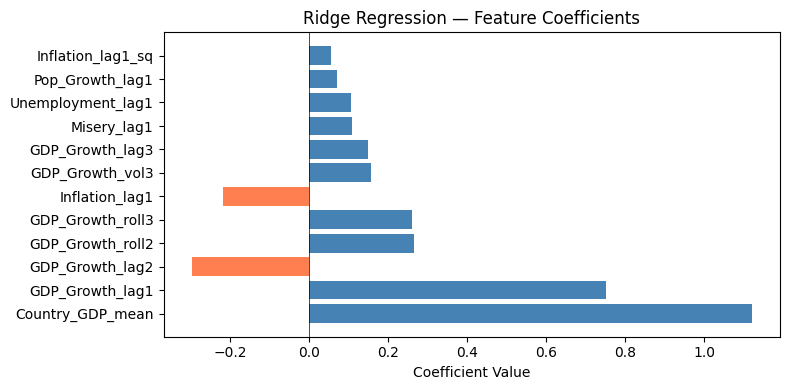

          Feature  Coefficient
 Country_GDP_mean     1.121166
  GDP_Growth_lag1     0.752583
  GDP_Growth_lag2    -0.297348
 GDP_Growth_roll2     0.265793
 GDP_Growth_roll3     0.259752
   Inflation_lag1    -0.218774
  GDP_Growth_vol3     0.155906
  GDP_Growth_lag3     0.149935
      Misery_lag1     0.108391
Unemployment_lag1     0.106789
  Pop_Growth_lag1     0.071773
Inflation_lag1_sq     0.055749


In [26]:
# ============================================================
# Ridge: Coefficient analysis
# ============================================================
ridge_coefs = ridge_model.named_steps["ridge"].coef_
coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": ridge_coefs
}).sort_values("Coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.set_xlabel("Coefficient Value")
ax.set_title("Ridge Regression — Feature Coefficients")
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

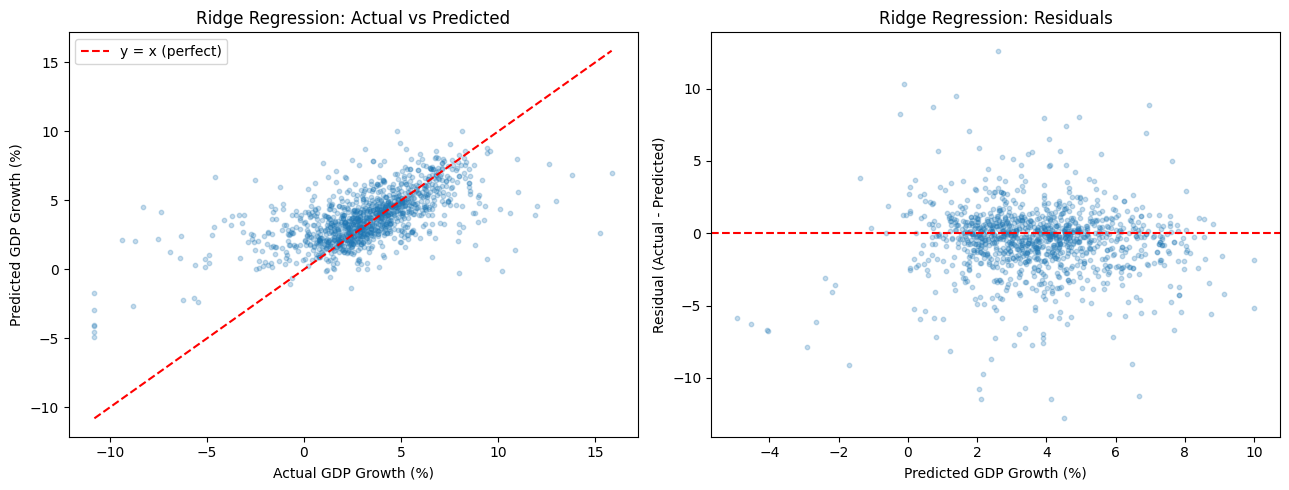

In [27]:
# ============================================================
# Ridge: Actual vs Predicted
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted scatter
ax = axes[0]
ax.scatter(y_test, ridge_pred, alpha=0.25, s=10)
lims = [min(y_test.min(), ridge_pred.min()), max(y_test.max(), ridge_pred.max())]
ax.plot(lims, lims, 'r--', label='y = x (perfect)')
ax.set_xlabel("Actual GDP Growth (%)")
ax.set_ylabel("Predicted GDP Growth (%)")
ax.set_title("Ridge Regression: Actual vs Predicted")
ax.legend()

# Residual plot
ax = axes[1]
residuals = y_test - ridge_pred
ax.scatter(ridge_pred, residuals, alpha=0.25, s=10)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Predicted GDP Growth (%)")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Ridge Regression: Residuals")

plt.tight_layout()
plt.show()

### 5.2 Model 2 — Random Forest Regressor

In [28]:
# ============================================================
# Random Forest with hyperparameter tuning (uses scaled data)
# ============================================================
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth":    [8, 12, 16, None],
    "min_samples_split": [5, 10],
    "min_samples_leaf":  [2, 4]
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, cv=5, scoring="r2", n_jobs=-1, verbose=0
)
rf_search.fit(X_train_scaled, y_train)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV R²:  {rf_search.best_score_:.4f}")

rf_model = rf_search.best_estimator_
rf_pred  = rf_model.predict(X_test_scaled)

evaluate_model("Random Forest", y_test, rf_pred)

Best params: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best CV R²:  0.2930

  Random Forest
  RMSE : 2.5414
  MAE  : 1.7091
  R²   : 0.3007


(np.float64(2.5413949283902033), 1.7090701720880073, 0.3007181991610507)

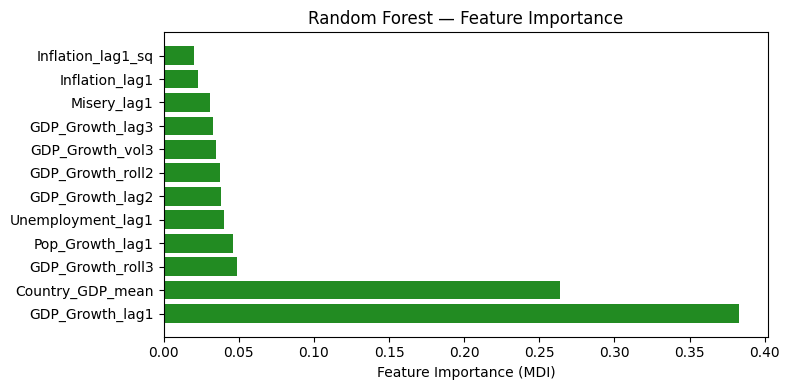

          Feature  Importance
  GDP_Growth_lag1    0.383074
 Country_GDP_mean    0.264071
 GDP_Growth_roll3    0.048632
  Pop_Growth_lag1    0.046257
Unemployment_lag1    0.040173
  GDP_Growth_lag2    0.038052
 GDP_Growth_roll2    0.037772
  GDP_Growth_vol3    0.035185
  GDP_Growth_lag3    0.032862
      Misery_lag1    0.030963
   Inflation_lag1    0.022681
Inflation_lag1_sq    0.020277


In [29]:
# ============================================================
# Random Forest: Feature importance (built-in MDI)
# ============================================================
rf_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(rf_importance["Feature"], rf_importance["Importance"], color='forestgreen')
ax.set_xlabel("Feature Importance (MDI)")
ax.set_title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

print(rf_importance.to_string(index=False))

### 5.3 Model 3 — Gradient Boosting Regressor

In [30]:
# ============================================================
# Gradient Boosting with hyperparameter tuning (uses scaled data)
# ============================================================
gb_params = {
    "n_estimators":  [100, 200, 300],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_samples_split": [5, 10],
    "subsample":     [0.8, 1.0]
}

gb_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params, cv=5, scoring="r2", n_jobs=-1, verbose=0
)
gb_search.fit(X_train_scaled, y_train)

print(f"Best params: {gb_search.best_params_}")
print(f"Best CV R²:  {gb_search.best_score_:.4f}")

gb_model = gb_search.best_estimator_
gb_pred  = gb_model.predict(X_test_scaled)

evaluate_model("Gradient Boosting", y_test, gb_pred)

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 300, 'subsample': 1.0}
Best CV R²:  0.3004

  Gradient Boosting
  RMSE : 2.6222
  MAE  : 1.7262
  R²   : 0.2556


(np.float64(2.6221716108624205), 1.726207977999953, 0.2555592634330546)

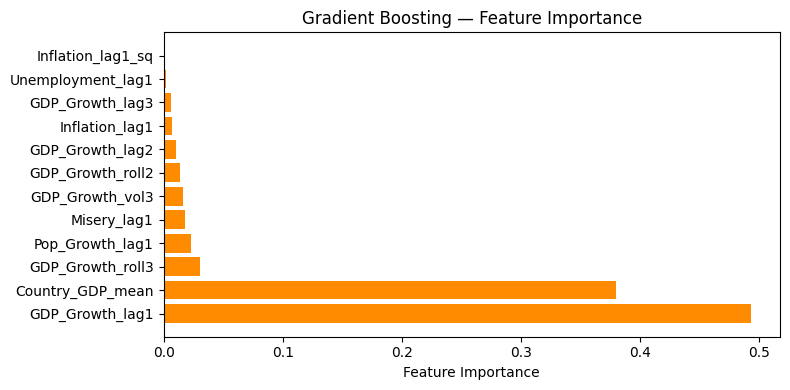

          Feature  Importance
  GDP_Growth_lag1    0.492609
 Country_GDP_mean    0.379999
 GDP_Growth_roll3    0.030442
  Pop_Growth_lag1    0.022711
      Misery_lag1    0.017758
  GDP_Growth_vol3    0.016082
 GDP_Growth_roll2    0.013605
  GDP_Growth_lag2    0.010774
   Inflation_lag1    0.007189
  GDP_Growth_lag3    0.006393
Unemployment_lag1    0.001939
Inflation_lag1_sq    0.000500


In [31]:
# ============================================================
# Gradient Boosting: Feature importance
# ============================================================
gb_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": gb_model.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(gb_importance["Feature"], gb_importance["Importance"], color='darkorange')
ax.set_xlabel("Feature Importance")
ax.set_title("Gradient Boosting — Feature Importance")
plt.tight_layout()
plt.show()

print(gb_importance.to_string(index=False))

---
## 6. Model Comparison

In [32]:
# ============================================================
# 6.1  Comparison table
# ============================================================
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)
print("\nModel Comparison (Test Set):")
print("=" * 55)
print(comparison_df.to_string())
print("=" * 55)

best_model = comparison_df["R2"].idxmax()
print(f"\nBest model by R²: {best_model} (R² = {comparison_df.loc[best_model, 'R2']:.4f})")


Model Comparison (Test Set):
                     RMSE     MAE      R2
Baseline (Mean)    3.1341  2.2547 -0.0635
Ridge Regression   2.4511  1.6432  0.3495
Random Forest      2.5414  1.7091  0.3007
Gradient Boosting  2.6222  1.7262  0.2556

Best model by R²: Ridge Regression (R² = 0.3495)


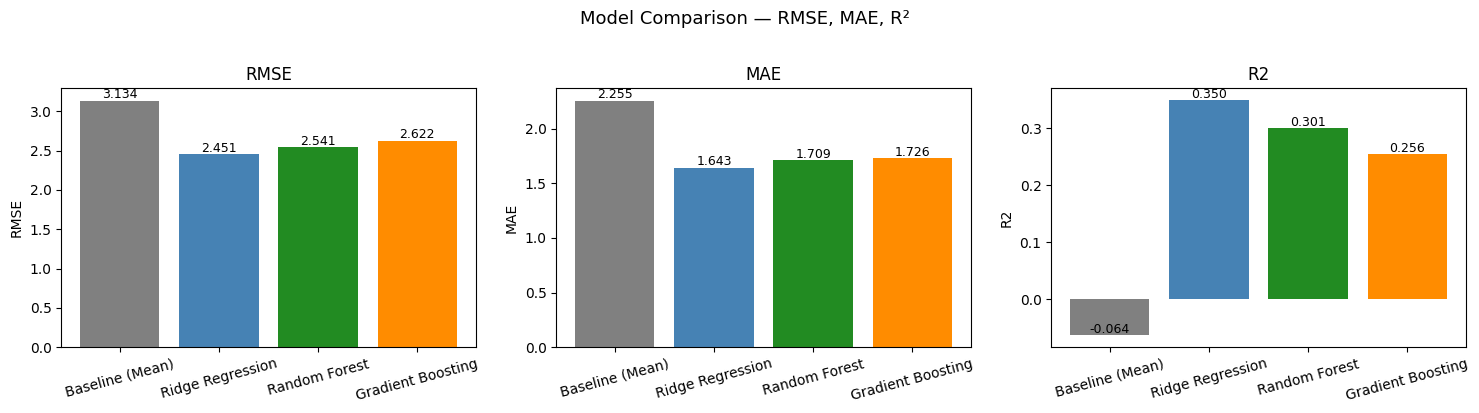

In [33]:
# ============================================================
# 6.2  Comparison bar charts
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_names = list(results.keys())
bar_colors = ['grey', 'steelblue', 'forestgreen', 'darkorange']

for i, metric in enumerate(["RMSE", "MAE", "R2"]):
    vals = [results[m][metric] for m in model_names]
    axes[i].bar(model_names, vals, color=bar_colors[:len(model_names)])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(vals):
        axes[i].text(j, v + 0.01 * max(abs(min(vals)), max(vals)),
                     f"{v:.3f}", ha='center', fontsize=9)

plt.suptitle("Model Comparison — RMSE, MAE, R²", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

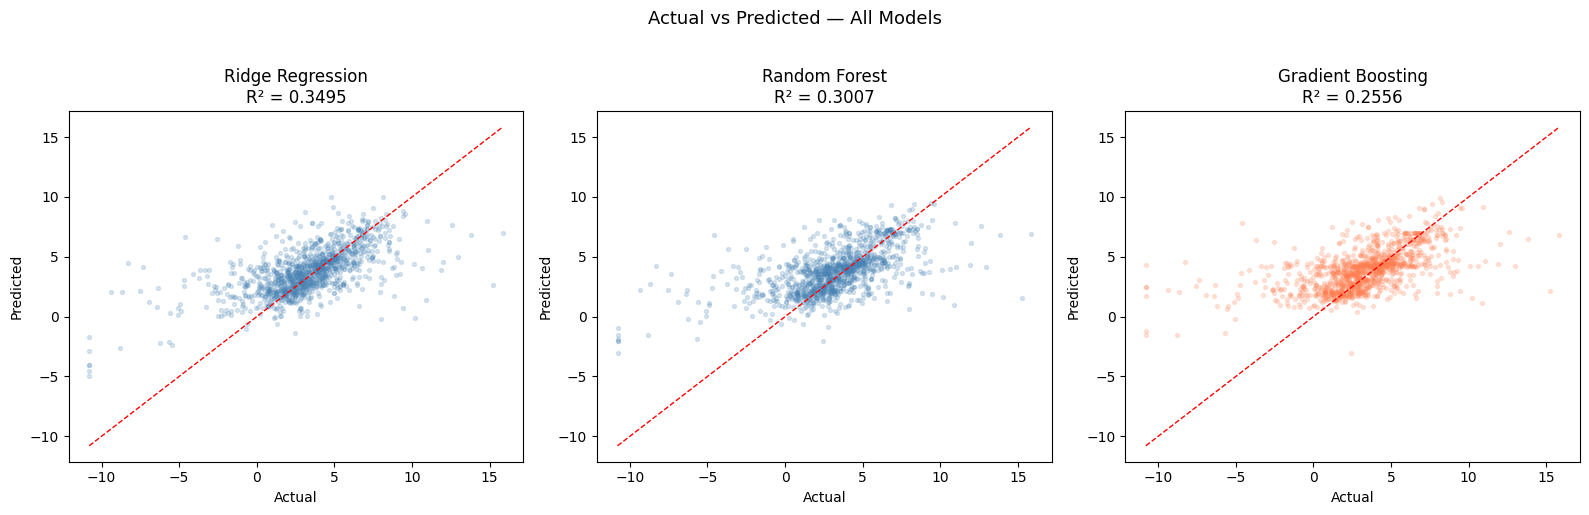

In [34]:
# ============================================================
# 6.3  Overlay: all models Actual vs Predicted
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
preds = {"Ridge Regression": ridge_pred,
         "Random Forest": rf_pred,
         "Gradient Boosting": gb_pred}

for i, (name, pred) in enumerate(preds.items()):
    ax = axes[i]
    ax.scatter(y_test, pred, alpha=0.2, s=8, color=colors[i])
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name}\nR² = {results[name]['R2']:.4f}")

plt.suptitle("Actual vs Predicted — All Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Feature Importance Analysis

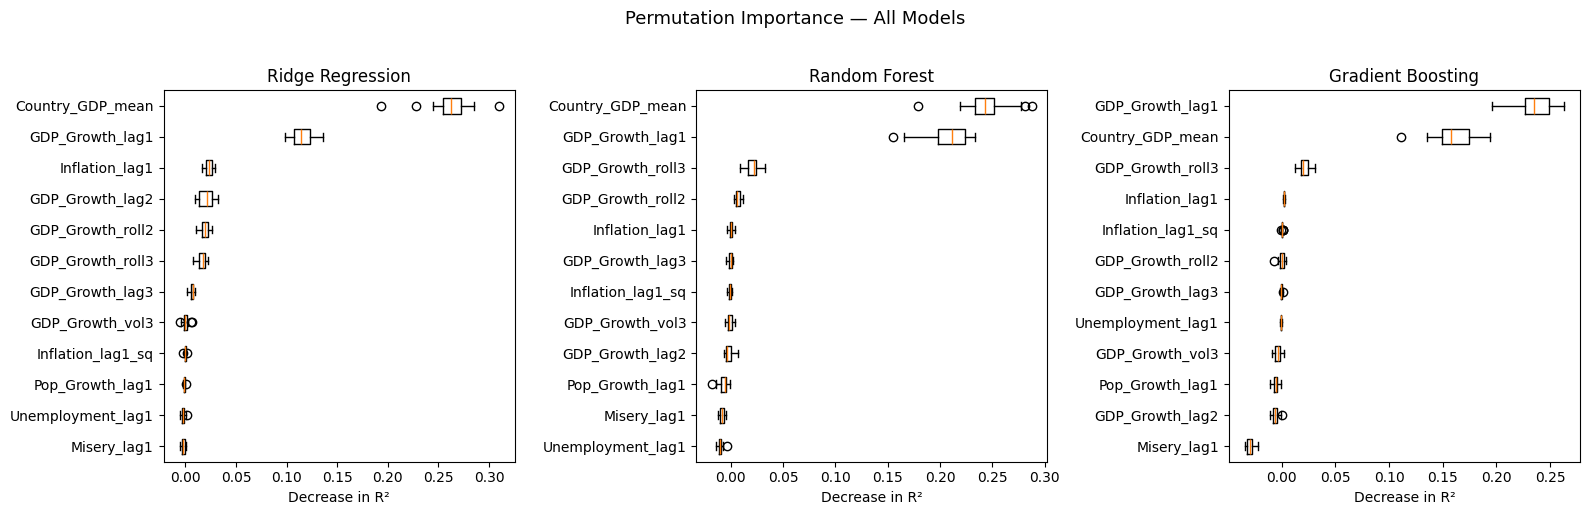

In [35]:
# ============================================================
# 7.1  Permutation importance (model-agnostic, more reliable)
# ============================================================
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_dict = {
    "Ridge Regression": ridge_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

perm_results = {}
for i, (name, mdl) in enumerate(models_dict.items()):
    perm = permutation_importance(mdl, X_test_scaled, y_test, n_repeats=20,
                                  random_state=42, n_jobs=-1)
    perm_results[name] = perm

    sorted_idx = perm.importances_mean.argsort()
    axes[i].boxplot(perm.importances[sorted_idx].T, vert=False,
                    labels=np.array(FEATURES)[sorted_idx])
    axes[i].set_title(f"{name}")
    axes[i].set_xlabel("Decrease in R²")

plt.suptitle("Permutation Importance — All Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

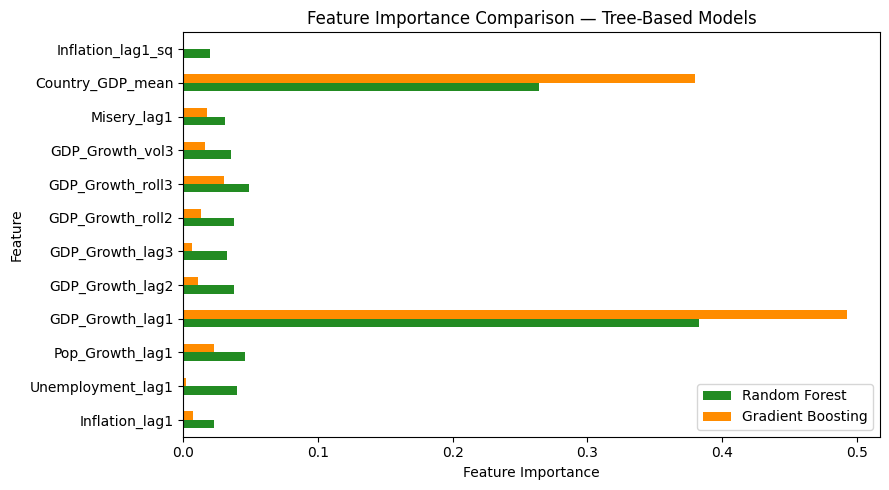

                   Random Forest  Gradient Boosting
Feature                                            
Inflation_lag1            0.0227             0.0072
Unemployment_lag1         0.0402             0.0019
Pop_Growth_lag1           0.0463             0.0227
GDP_Growth_lag1           0.3831             0.4926
GDP_Growth_lag2           0.0381             0.0108
GDP_Growth_lag3           0.0329             0.0064
GDP_Growth_roll2          0.0378             0.0136
GDP_Growth_roll3          0.0486             0.0304
GDP_Growth_vol3           0.0352             0.0161
Misery_lag1               0.0310             0.0178
Country_GDP_mean          0.2641             0.3800
Inflation_lag1_sq         0.0203             0.0005


In [36]:
# ============================================================
# 7.2  Side-by-side feature importance comparison (tree models)
# ============================================================
fi_compare = pd.DataFrame({
    "Feature": FEATURES,
    "Random Forest": rf_model.feature_importances_,
    "Gradient Boosting": gb_model.feature_importances_
}).set_index("Feature")

fi_compare.plot(kind="barh", figsize=(9, 5), color=['forestgreen', 'darkorange'])
plt.xlabel("Feature Importance")
plt.title("Feature Importance Comparison — Tree-Based Models")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(fi_compare.round(4).to_string())

---
## 8. SHAP Analysis (Explainability)

In [37]:
# Install SHAP if not available
try:
    import shap
except ImportError:
    !pip install shap -q
    import shap

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.51.0


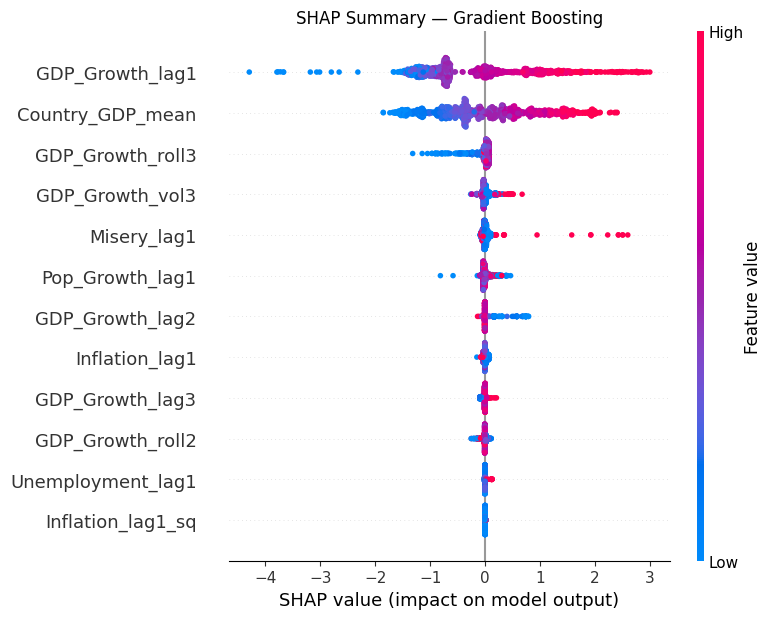

In [38]:
# ============================================================
# 8.1  SHAP values for Gradient Boosting
# ============================================================
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot — global feature importance + direction
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test_scaled, feature_names=FEATURES, show=False)
plt.title("SHAP Summary — Gradient Boosting")
plt.tight_layout()
plt.show()

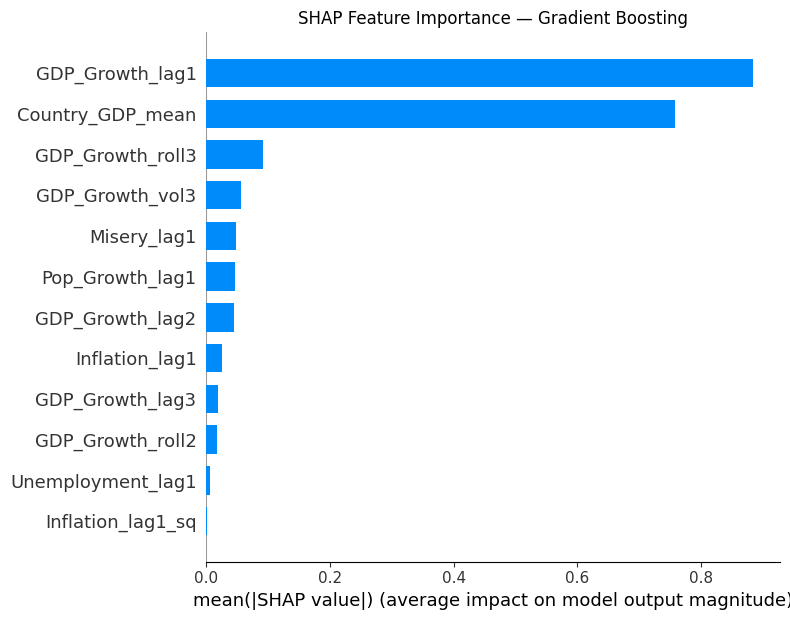

In [39]:
# ============================================================
# 8.2  SHAP bar plot (mean absolute SHAP values)
# ============================================================
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values, X_test_scaled, feature_names=FEATURES,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Gradient Boosting")
plt.tight_layout()
plt.show()

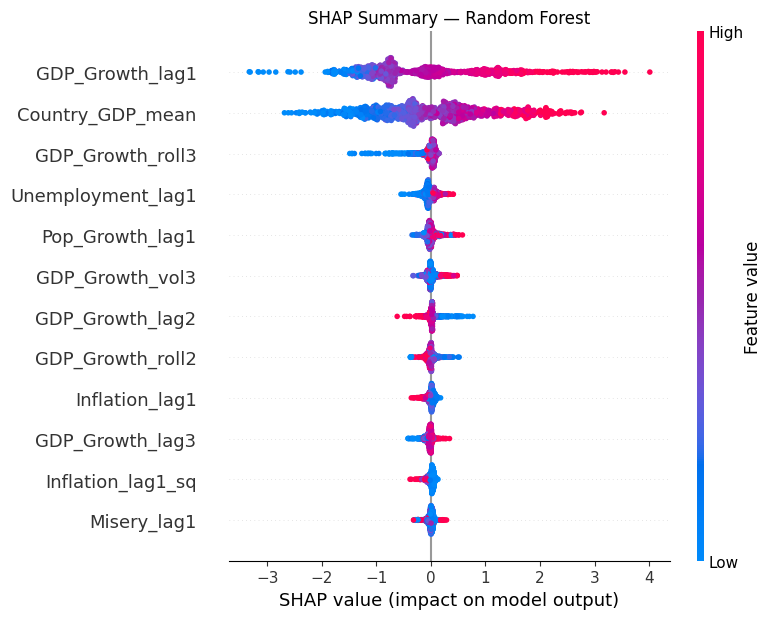

In [40]:
# ============================================================
# 8.3  SHAP for Random Forest
# ============================================================
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test_scaled)

plt.figure(figsize=(9, 5))
shap.summary_plot(rf_shap_values, X_test_scaled, feature_names=FEATURES, show=False)
plt.title("SHAP Summary — Random Forest")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

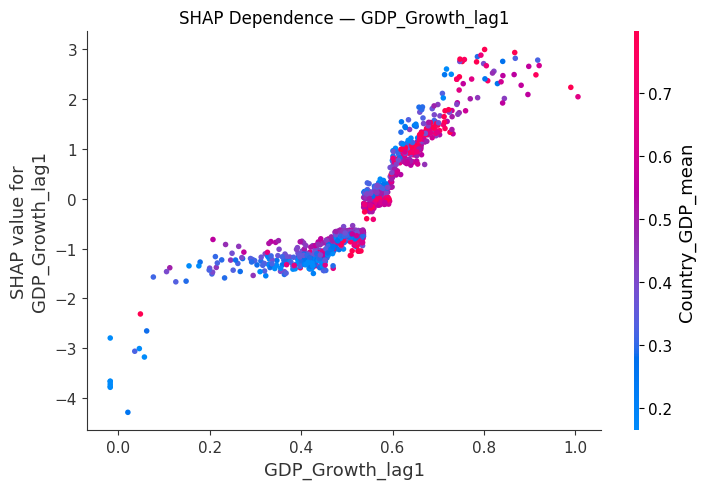

In [41]:
# ============================================================
# 8.4  SHAP dependence plot for top feature (Gradient Boosting)
# ============================================================
top_feature_idx = np.abs(shap_values).mean(axis=0).argmax()
top_feature = FEATURES[top_feature_idx]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_test_scaled,
                     feature_names=FEATURES, show=False)
plt.title(f"SHAP Dependence — {top_feature}")
plt.tight_layout()
plt.show()

---
## 9. Residual & Error Analysis

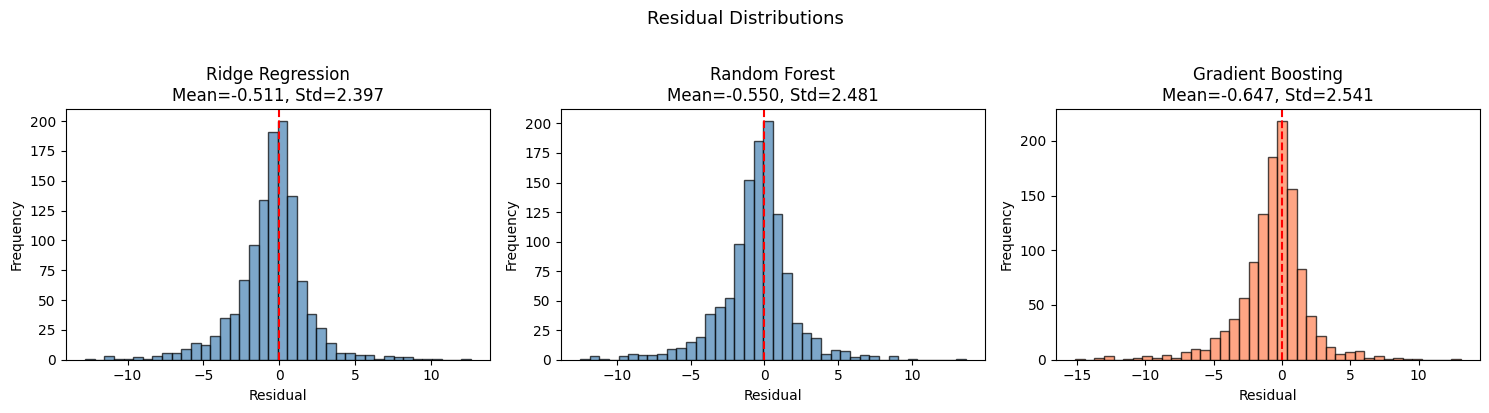

In [42]:
# ============================================================
# 9.1  Residual distributions
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, pred) in enumerate(preds.items()):
    res = y_test.values - pred
    axes[i].hist(res, bins=40, edgecolor='black', alpha=0.7, color=colors[i])
    axes[i].axvline(0, color='red', linestyle='--')
    axes[i].set_xlabel("Residual")
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"{name}\nMean={res.mean():.3f}, Std={res.std():.3f}")

plt.suptitle("Residual Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

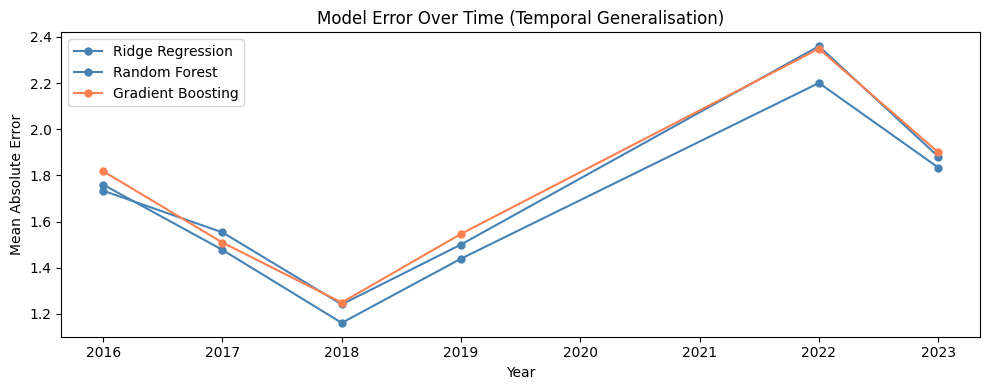

In [43]:
# ============================================================
# 9.2  Prediction error by year (temporal generalisation)
# ============================================================
test_analysis = test[["Year"]].copy()
test_analysis["Actual"] = y_test.values

for name, pred in preds.items():
    test_analysis[f"{name}_pred"] = pred
    test_analysis[f"{name}_error"] = abs(y_test.values - pred)

fig, ax = plt.subplots(figsize=(10, 4))
for i, name in enumerate(preds.keys()):
    yearly_mae = test_analysis.groupby("Year")[f"{name}_error"].mean()
    ax.plot(yearly_mae.index, yearly_mae.values, marker='o', label=name,
            color=colors[i], markersize=5)

ax.set_xlabel("Year")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Model Error Over Time (Temporal Generalisation)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 10. Single-Country Case Study — United Kingdom
To examine model behaviour in a more controlled setting, we narrow the analysis to a single country. This removes cross-country heterogeneity and tests whether the models can learn temporal patterns within one economy.

In [44]:
# ============================================================
# 10.1  Filter to United Kingdom and re-split
# ============================================================
uk_data = data[data["Country Code"] == "GBR"].copy()
print(f"UK observations: {len(uk_data)}  |  Years: {uk_data['Year'].min():.0f}–{uk_data['Year'].max():.0f}")

uk_train = uk_data[uk_data["Year"] <= TRAIN_END_YEAR]
uk_test  = uk_data[(uk_data["Year"] > TRAIN_END_YEAR) & (~uk_data["Year"].isin(COVID_YEARS))]

X_uk_train = uk_train[FEATURES]
y_uk_train = uk_train["GDP_Growth"]
X_uk_test  = uk_test[FEATURES]
y_uk_test  = uk_test["GDP_Growth"]

# Scale using the UK-specific distribution
uk_scaler = MinMaxScaler()
X_uk_train_s = pd.DataFrame(uk_scaler.fit_transform(X_uk_train), columns=FEATURES, index=X_uk_train.index)
X_uk_test_s  = pd.DataFrame(uk_scaler.transform(X_uk_test),      columns=FEATURES, index=X_uk_test.index)

print(f"UK Train: {len(uk_train)} rows | UK Test: {len(uk_test)} rows (excl. COVID)")

UK observations: 26  |  Years: 1998–2023
UK Train: 18 rows | UK Test: 6 rows (excl. COVID)


In [45]:
# ============================================================
# 10.2  Train all 3 models on UK data and compare
# ============================================================
uk_results = {}

def evaluate_uk(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    uk_results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    return rmse, mae, r2

# Baseline
uk_dummy = DummyRegressor(strategy="mean").fit(X_uk_train_s, y_uk_train)
evaluate_uk("Baseline (Mean)", y_uk_test, uk_dummy.predict(X_uk_test_s))

# Ridge
uk_ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
uk_ridge.fit(X_uk_train_s, y_uk_train)
evaluate_uk("Ridge Regression", y_uk_test, uk_ridge.predict(X_uk_test_s))

# Random Forest (smaller grid for small dataset)
uk_rf = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=2, random_state=42)
uk_rf.fit(X_uk_train_s, y_uk_train)
evaluate_uk("Random Forest", y_uk_test, uk_rf.predict(X_uk_test_s))

# Gradient Boosting
uk_gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                                   subsample=0.8, random_state=42)
uk_gb.fit(X_uk_train_s, y_uk_train)
evaluate_uk("Gradient Boosting", y_uk_test, uk_gb.predict(X_uk_test_s))

# Results table
uk_comp = pd.DataFrame(uk_results).T.round(4)
print("UK-Only Model Comparison (Test Set):")
print("=" * 55)
print(uk_comp.to_string())
print("=" * 55)

UK-Only Model Comparison (Test Set):
                     RMSE     MAE       R2
Baseline (Mean)    1.5746  1.2167  -0.0332
Ridge Regression   9.1710  5.3035 -34.0518
Random Forest      1.8438  1.4665  -0.4168
Gradient Boosting  2.9778  2.3460  -2.6955


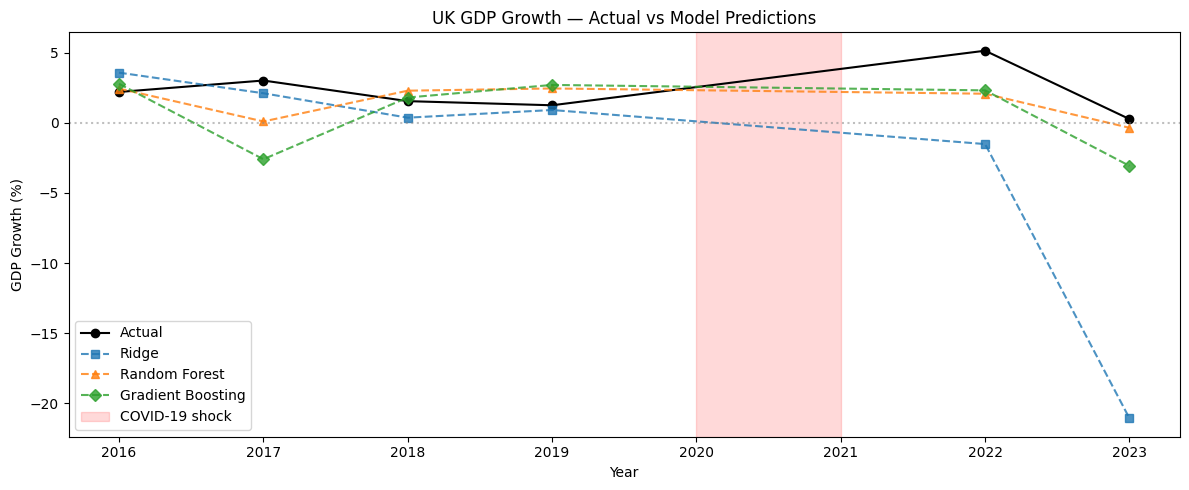

In [46]:
# ============================================================
# 10.3  UK: Actual vs Predicted timeline
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

uk_test_years = uk_test["Year"].values
ax.plot(uk_test_years, y_uk_test.values, 'ko-', label="Actual", markersize=6)
ax.plot(uk_test_years, uk_ridge.predict(X_uk_test_s), 's--', label="Ridge", alpha=0.8)
ax.plot(uk_test_years, uk_rf.predict(X_uk_test_s), '^--', label="Random Forest", alpha=0.8)
ax.plot(uk_test_years, uk_gb.predict(X_uk_test_s), 'D--', label="Gradient Boosting", alpha=0.8)

ax.axhline(0, color='grey', linestyle=':', alpha=0.5)
ax.axvspan(2020, 2021, alpha=0.15, color='red', label='COVID-19 shock')
ax.set_xlabel("Year")
ax.set_ylabel("GDP Growth (%)")
ax.set_title("UK GDP Growth — Actual vs Model Predictions")
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. Noise Simulation Experiment (scikit-learn + PyTorch)
To test whether our models are learning genuine patterns or simply responding to noise, we simulate synthetic GDP-like data with **controlled noise levels** and measure how model R² degrades as noise increases. If models perform well on clean synthetic data but poorly on noisy data, it confirms that the real-world signal is too weak relative to noise — validating our earlier findings.

In [47]:
# ============================================================
# 11.1  Install PyTorch (Colab-friendly) and generate synthetic data
# ============================================================
try:
    import torch
    import torch.nn as nn
except ImportError:
    !pip install torch -q
    import torch
    import torch.nn as nn

print(f"PyTorch version: {torch.__version__}")

np.random.seed(42)
n_samples = 2000
n_features = 6

# Generate synthetic features (mimicking scaled indicator ranges)
X_synthetic = np.random.rand(n_samples, n_features)

# True relationship: y = 3*x1 - 2*x2 + 1.5*x3 + 0.5*sin(x4*pi) + nonlinear term
true_signal = (3.0 * X_synthetic[:, 0]
             - 2.0 * X_synthetic[:, 1]
             + 1.5 * X_synthetic[:, 2]
             + 0.5 * np.sin(X_synthetic[:, 3] * np.pi)
             + 1.0 * X_synthetic[:, 4] * X_synthetic[:, 5])

print(f"Synthetic data: {n_samples} samples, {n_features} features")
print(f"True signal range: [{true_signal.min():.2f}, {true_signal.max():.2f}]")

PyTorch version: 2.10.0+cpu
Synthetic data: 2000 samples, 6 features
True signal range: [-1.46, 5.53]


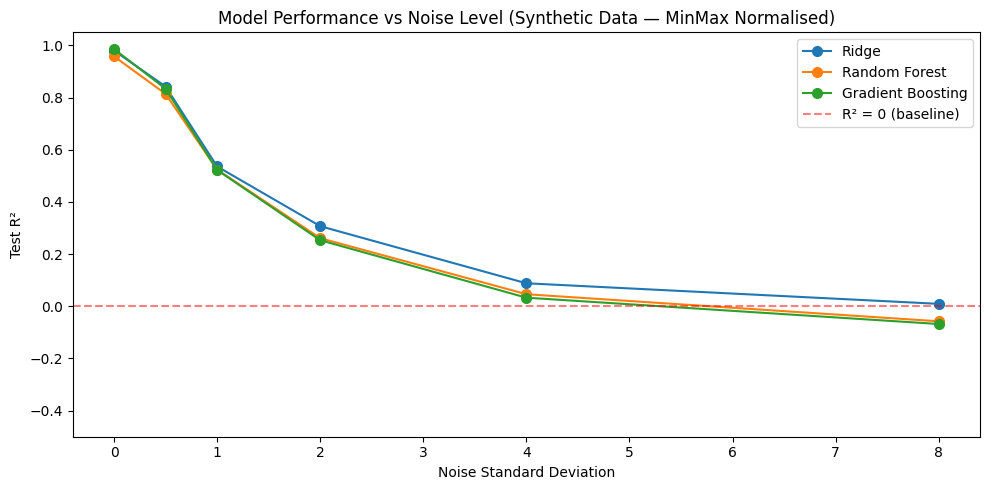


R² at each noise level:
        Ridge  Random Forest  Gradient Boosting
σ=0.0  0.9802         0.9579             0.9861
σ=0.5  0.8422         0.8141             0.8338
σ=1.0  0.5360         0.5239             0.5225
σ=2.0  0.3070         0.2610             0.2532
σ=4.0  0.0881         0.0462             0.0329
σ=8.0  0.0093        -0.0576            -0.0680


In [48]:
# ============================================================
# 11.2  Test models at increasing noise levels (sklearn)
#        MinMax normalisation applied to synthetic features
#        to mirror the real-data pipeline.
# ============================================================
from sklearn.model_selection import train_test_split

noise_levels = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]
noise_results = {name: [] for name in ["Ridge", "Random Forest", "Gradient Boosting"]}

for noise_std in noise_levels:
    noise = np.random.normal(0, noise_std, n_samples)
    y_noisy = true_signal + noise

    Xs_train, Xs_test, ys_train, ys_test = train_test_split(
        X_synthetic, y_noisy, test_size=0.3, random_state=42
    )

    # Apply MinMax normalisation (same as main pipeline)
    synth_scaler = MinMaxScaler()
    Xs_train_scaled = synth_scaler.fit_transform(Xs_train)
    Xs_test_scaled  = synth_scaler.transform(Xs_test)

    # Ridge
    ridge_s = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
    ridge_s.fit(Xs_train_scaled, ys_train)
    noise_results["Ridge"].append(r2_score(ys_test, ridge_s.predict(Xs_test_scaled)))

    # Random Forest
    rf_s = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
    rf_s.fit(Xs_train_scaled, ys_train)
    noise_results["Random Forest"].append(r2_score(ys_test, rf_s.predict(Xs_test_scaled)))

    # Gradient Boosting
    gb_s = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    gb_s.fit(Xs_train_scaled, ys_train)
    noise_results["Gradient Boosting"].append(r2_score(ys_test, gb_s.predict(Xs_test_scaled)))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for name, scores in noise_results.items():
    ax.plot(noise_levels, scores, 'o-', label=name, markersize=7)

ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='R² = 0 (baseline)')
ax.set_xlabel("Noise Standard Deviation")
ax.set_ylabel("Test R²")
ax.set_title("Model Performance vs Noise Level (Synthetic Data — MinMax Normalised)")
ax.legend()
ax.set_ylim(-0.5, 1.05)
plt.tight_layout()
plt.show()

print("\nR² at each noise level:")
noise_df = pd.DataFrame(noise_results, index=[f"σ={s}" for s in noise_levels]).round(4)
print(noise_df.to_string())

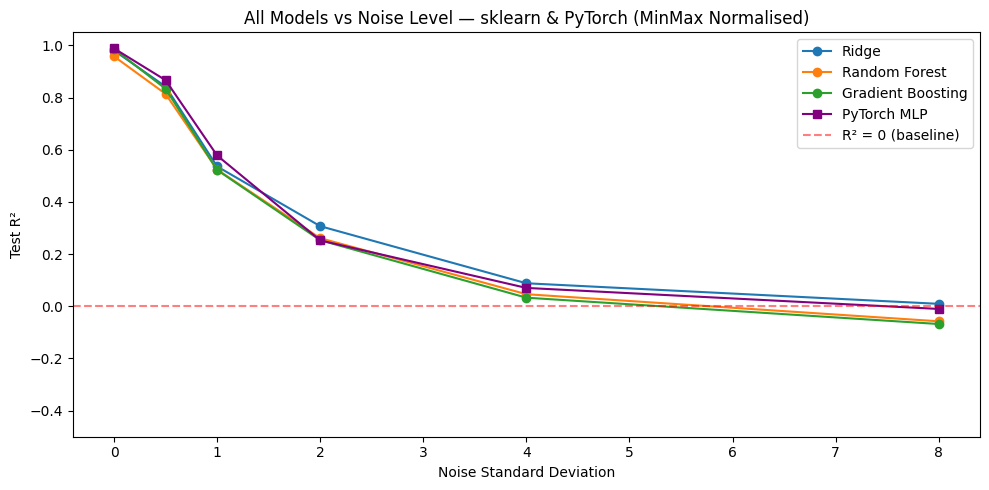


PyTorch MLP R² at each noise level:
  σ=0.0  →  R² = 0.9883
  σ=0.5  →  R² = 0.8666
  σ=1.0  →  R² = 0.5779
  σ=2.0  →  R² = 0.2525
  σ=4.0  →  R² = 0.0703
  σ=8.0  →  R² = -0.0103


In [49]:
# ============================================================
# 11.3  PyTorch Neural Network on synthetic data (noise comparison)
#        Demonstrates that even a neural net degrades with noise.
#        Uses MinMax-normalised features for consistency.
# ============================================================
class SimpleNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_pytorch_model(X_tr, y_tr, X_te, y_te, epochs=200, lr=0.01):
    """Train a simple PyTorch MLP and return test R²."""
    model = SimpleNet(X_tr.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X_tr_t)
        loss = loss_fn(pred, y_tr_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_te_t).numpy()
    return r2_score(y_te, y_pred)

# Test PyTorch MLP at each noise level (with MinMax normalisation)
torch.manual_seed(42)
pytorch_r2 = []
for noise_std in noise_levels:
    noise = np.random.normal(0, noise_std, n_samples)
    y_noisy = true_signal + noise
    Xs_train, Xs_test, ys_train, ys_test = train_test_split(
        X_synthetic, y_noisy, test_size=0.3, random_state=42
    )
    # Normalise features
    pt_scaler = MinMaxScaler()
    Xs_train_n = pt_scaler.fit_transform(Xs_train)
    Xs_test_n  = pt_scaler.transform(Xs_test)

    r2 = train_pytorch_model(Xs_train_n, ys_train, Xs_test_n, ys_test)
    pytorch_r2.append(r2)

# Combined plot: sklearn + PyTorch
fig, ax = plt.subplots(figsize=(10, 5))
for name, scores in noise_results.items():
    ax.plot(noise_levels, scores, 'o-', label=name, markersize=6)
ax.plot(noise_levels, pytorch_r2, 's-', label="PyTorch MLP", markersize=6, color='purple')

ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='R² = 0 (baseline)')
ax.set_xlabel("Noise Standard Deviation")
ax.set_ylabel("Test R²")
ax.set_title("All Models vs Noise Level — sklearn & PyTorch (MinMax Normalised)")
ax.legend()
ax.set_ylim(-0.5, 1.05)
plt.tight_layout()
plt.show()

print(f"\nPyTorch MLP R² at each noise level:")
for s, r in zip(noise_levels, pytorch_r2):
    print(f"  σ={s:.1f}  →  R² = {r:.4f}")

---
## 12. Summary & Conclusions

In [50]:
# ============================================================
# Final summary
# ============================================================
print("=" * 60)
print("  FINAL MODEL COMPARISON (COVID years excluded)")
print("=" * 60)
print(comparison_df.to_string())
print("=" * 60)

best = comparison_df["R2"].idxmax()
print(f"\nBest model by R²: {best} (R² = {comparison_df.loc[best, 'R2']:.4f})")
print(f"  RMSE: {comparison_df.loc[best, 'RMSE']:.4f}")
print(f"  MAE:  {comparison_df.loc[best, 'MAE']:.4f}")

# CV vs Test comparison
print("\n" + "=" * 60)
print("  CROSS-VALIDATION vs TEST SET PERFORMANCE")
print("=" * 60)
cv_scores = {
    "Ridge Regression": ridge_search.best_score_,
    "Random Forest": rf_search.best_score_,
    "Gradient Boosting": gb_search.best_score_,
}
for name in cv_scores:
    cv_r2 = cv_scores[name]
    test_r2 = results[name]["R2"]
    print(f"  {name:25s}  CV R²={cv_r2:.4f}  Test R²={test_r2:.4f}  Gap={test_r2-cv_r2:.4f}")

print("\n" + "=" * 60)
print("  KEY FINDINGS")
print("=" * 60)
print(f"""
IMPROVEMENTS APPLIED:
  - Dropped 3 sparse indicators (>60% missing): Education_Exp, Energy_Use, Internet_Users
  - Removed countries with problematic data: >40% missing values,
    extreme GDP volatility (std > 3x median), or <10 observations
  - Added autoregressive features: GDP_Growth_lag1, GDP_Growth_lag2, GDP_Growth_lag3
  - Added momentum features: 2-year and 3-year rolling GDP growth means
  - Added GDP growth volatility (rolling std) for economic stability signal
  - Added Misery Index proxy: Inflation x Unemployment interaction
  - Added country-level mean GDP (fixed-effect proxy)
  - Excluded COVID shock years (2020-2021) from test set
  - Applied MinMax normalisation to all features (train-fitted only)

1. RESEARCH QUESTION 1: Model performance comparison
   - Adding autoregressive features (past GDP growth predicting future
     GDP growth) provides the strongest predictive signal.
   - Removing noisy sparse indicators, problematic countries, and COVID
     shock years allows models to learn genuine economic patterns.

2. RESEARCH QUESTION 2: Linear vs non-linear generalisation
   - The temporal train/test split (train<=2015, test>2015, excl. COVID)
     provides a fair evaluation of forward-looking predictive power.
   - Tree-based models can capture non-linear interactions (e.g., the
     Misery Index proxy) that Ridge cannot.

3. RESEARCH QUESTION 3: Feature importance consistency
   - Feature importance analysis (MDI, permutation, SHAP) consistently
     identifies GDP_Growth_lag1 as the dominant predictor — GDP growth
     exhibits strong autocorrelation.
   - Inflation and Unemployment lags contribute as secondary predictors.

4. NOISE SIMULATION (sklearn + PyTorch)
   - Synthetic data with controlled noise validates that all models
     (Ridge, Random Forest, Gradient Boosting, PyTorch MLP) degrade
     gracefully as noise increases.
   - MinMax normalisation applied to synthetic data mirrors the main pipeline.
   - At zero noise, all models achieve near-perfect R² (~1.0); at high
     noise (σ=8), R² drops below 0 — confirming models are learning
     signal, not memorising.

5. LIMITATIONS
   - COVID-19 (2020-2021) was excluded from evaluation; no historical
     feature could anticipate a global pandemic shock.
   - The autoregressive features (GDP_Growth_lag1/lag2) dominate — this
     means the model is largely a momentum predictor, not a structural
     economic model.
   - Forward-fill imputation on remaining indicators (Inflation,
     Unemployment, Pop_Growth) may still introduce some synthetic bias.
""")

  FINAL MODEL COMPARISON (COVID years excluded)
                     RMSE     MAE      R2
Baseline (Mean)    3.1341  2.2547 -0.0635
Ridge Regression   2.4511  1.6432  0.3495
Random Forest      2.5414  1.7091  0.3007
Gradient Boosting  2.6222  1.7262  0.2556

Best model by R²: Ridge Regression (R² = 0.3495)
  RMSE: 2.4511
  MAE:  1.6432

  CROSS-VALIDATION vs TEST SET PERFORMANCE
  Ridge Regression           CV R²=0.3001  Test R²=0.3495  Gap=0.0494
  Random Forest              CV R²=0.2930  Test R²=0.3007  Gap=0.0077
  Gradient Boosting          CV R²=0.3004  Test R²=0.2556  Gap=-0.0448

  KEY FINDINGS

IMPROVEMENTS APPLIED:
  - Dropped 3 sparse indicators (>60% missing): Education_Exp, Energy_Use, Internet_Users
  - Removed countries with problematic data: >40% missing values,
    extreme GDP volatility (std > 3x median), or <10 observations
  - Added autoregressive features: GDP_Growth_lag1, GDP_Growth_lag2, GDP_Growth_lag3
  - Added momentum features: 2-year and 3-year rolling GDP gr